In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Este notebook aproxima el valor de una put americana con regresión lineal.


In [2]:
# Parámetros del modelo
r = 0.06  # tasa de interés
sigma = 0.2  # volatilidad

dt = 1/12  # periodo de decisión en años
T = 3  # tiempo de vencimiento en años
alpha = np.exp(-r * dt)  # factor de descuento
S0 = 1  # precio inicial del activo
K = 1.1  # precio de ejercicio
M = 10000  # número de trayectorias simuladas
N = 5  # número de funciones básicas
T = int(T / dt)  # número total de periodos


In [3]:
# Simulamos trayectorias del precio del activo
S = np.zeros((M, T + 1))
for i in range(M):
    S[i, 0] = S0
    for t in range(1, T + 1):
        S[i, t] = S[i, t - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * np.sqrt(dt) * np.random.randn())


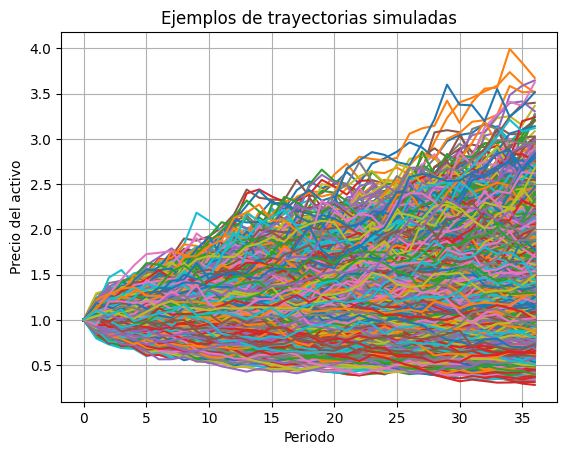

In [4]:
for tt in S:
    plt.plot(tt)
plt.grid(True)
plt.xlabel("Periodo")
plt.ylabel("Precio del activo")
plt.title("Ejemplos de trayectorias simuladas")
plt.show()


In [5]:
# Definimos las funciones básicas usadas para aproximar la función valor
def Phi(s):
    return np.array([1] + [s**i for i in range(1, N + 1)])


In [6]:
N = 5
Phi(1.2)


array([1.     , 1.2    , 1.44   , 1.728  , 2.0736 , 2.48832])

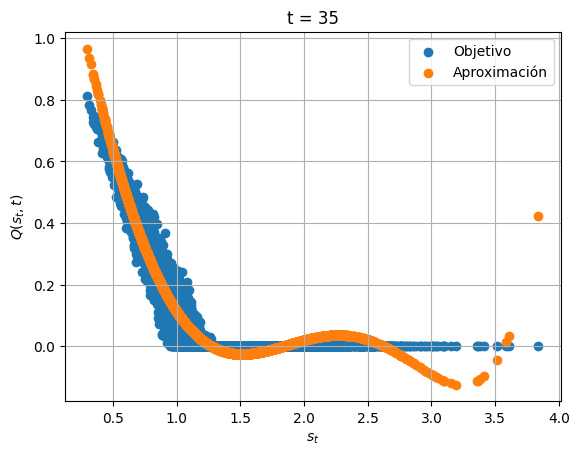

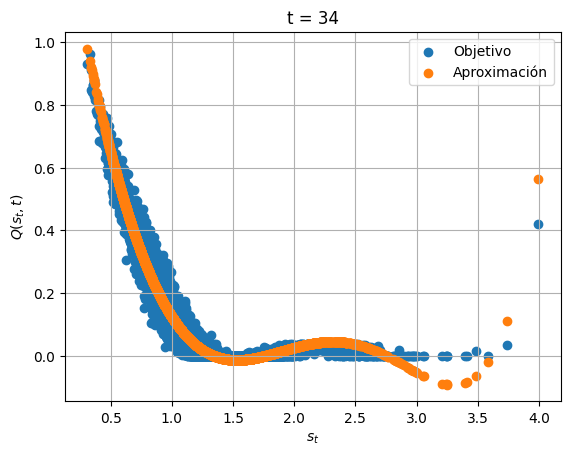

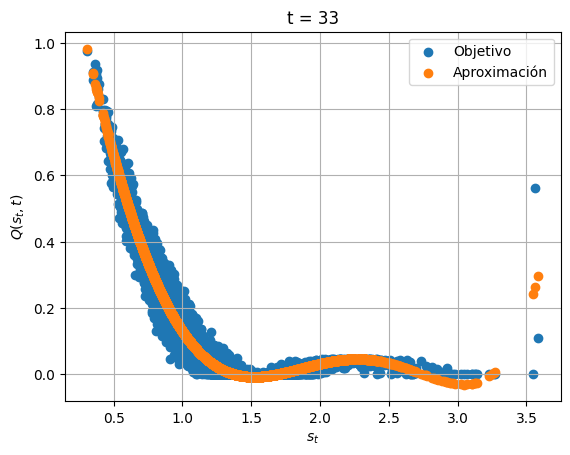

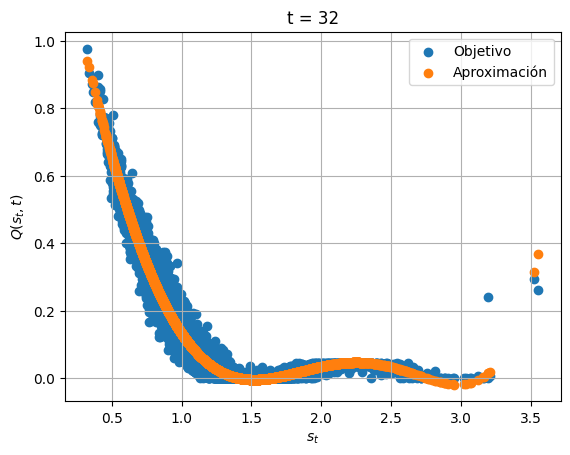

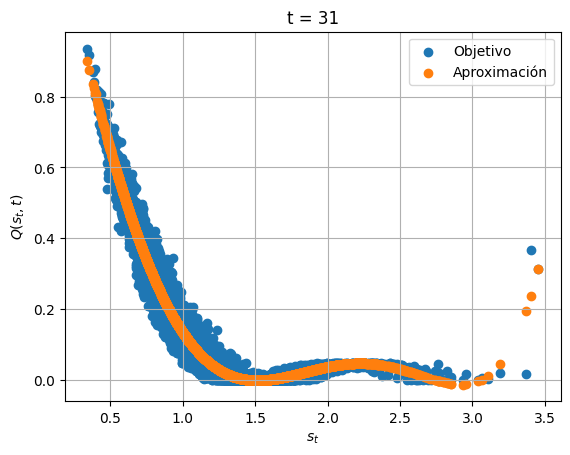

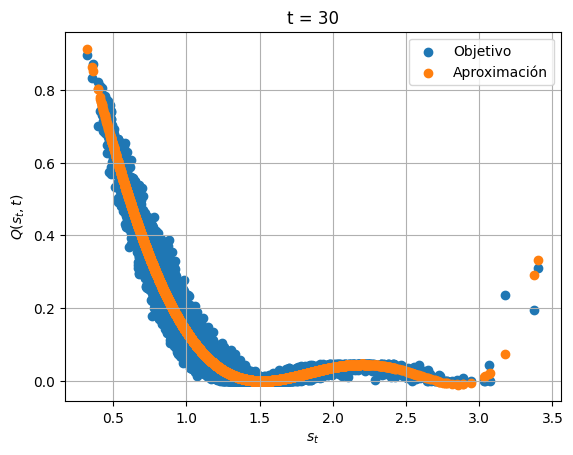

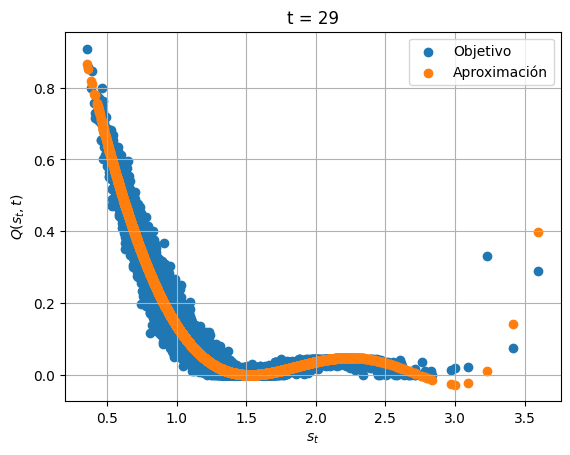

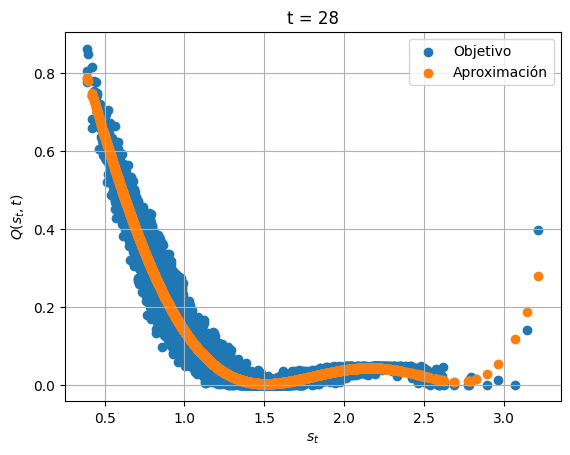

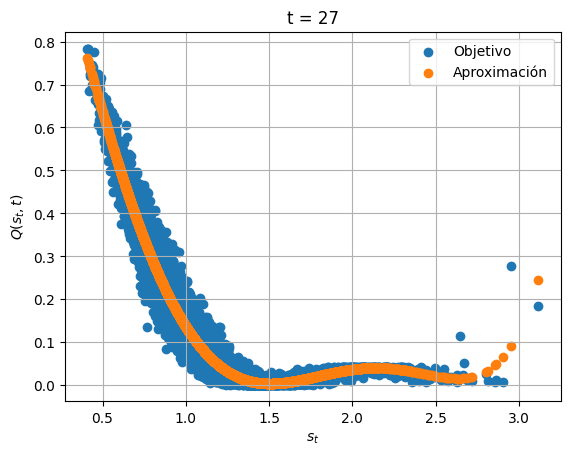

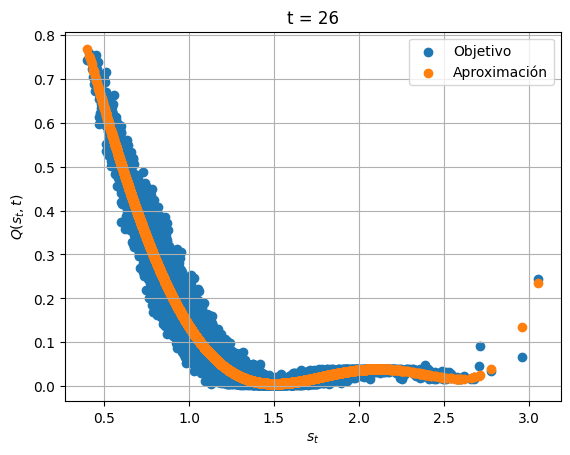

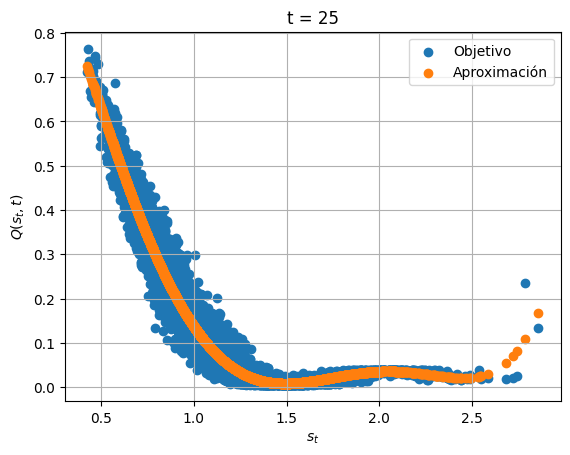

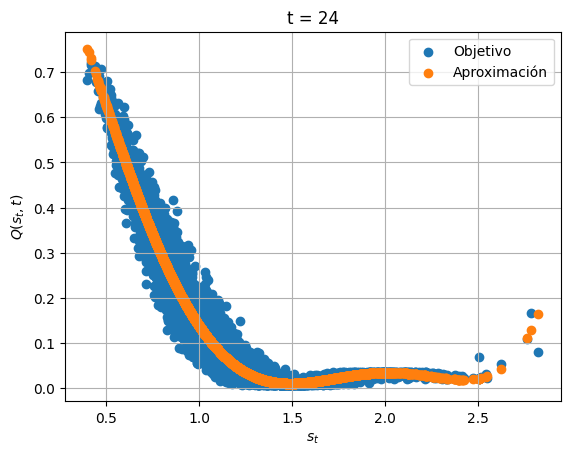

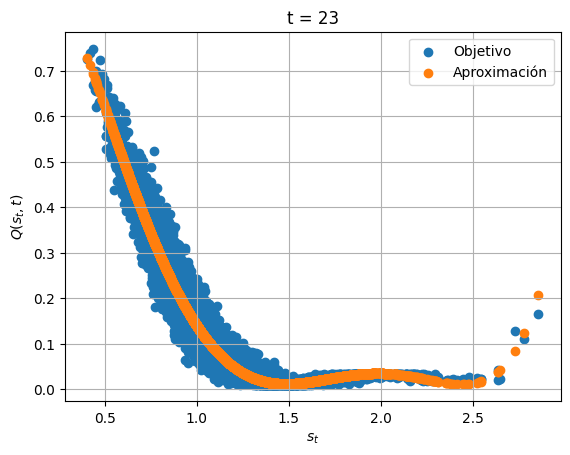

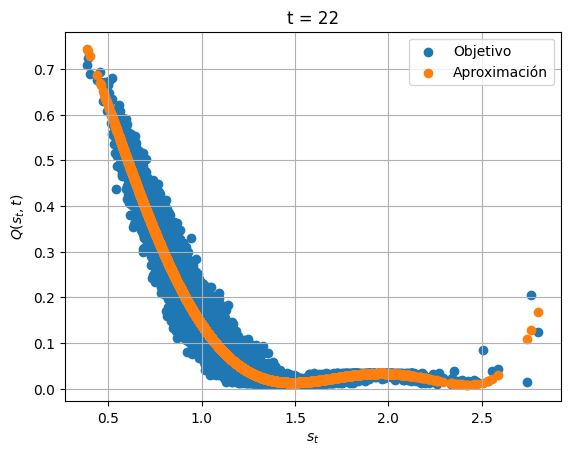

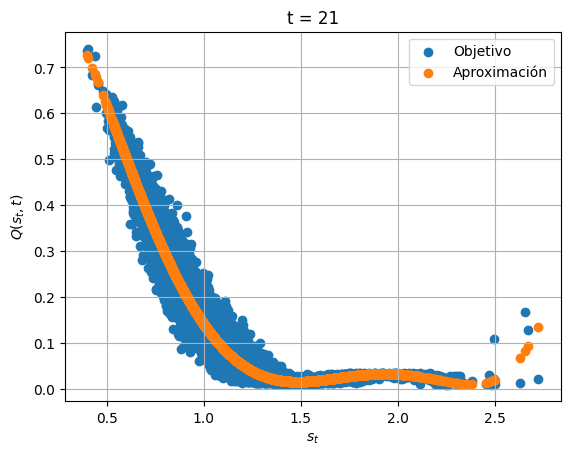

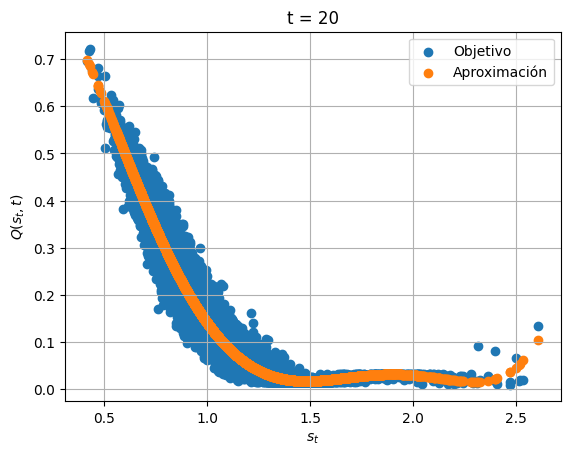

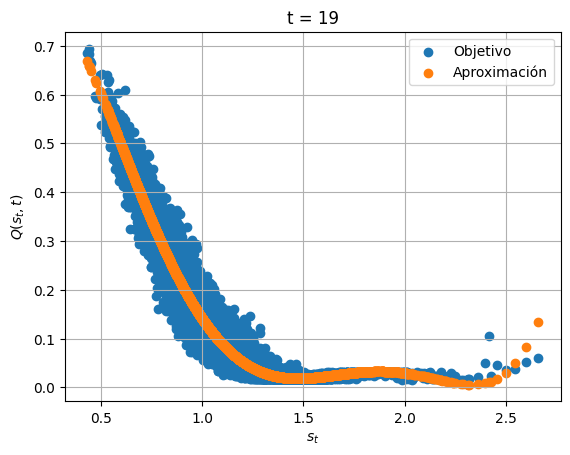

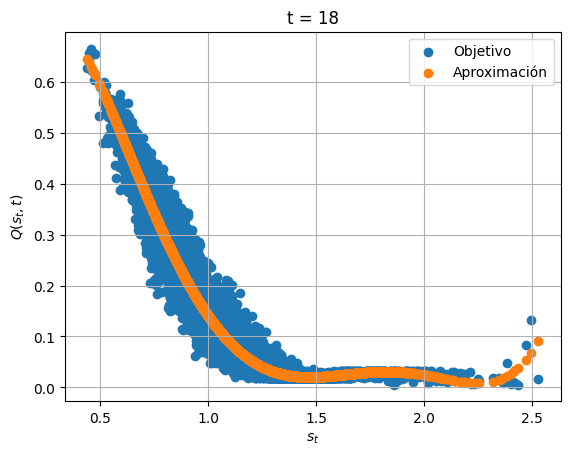

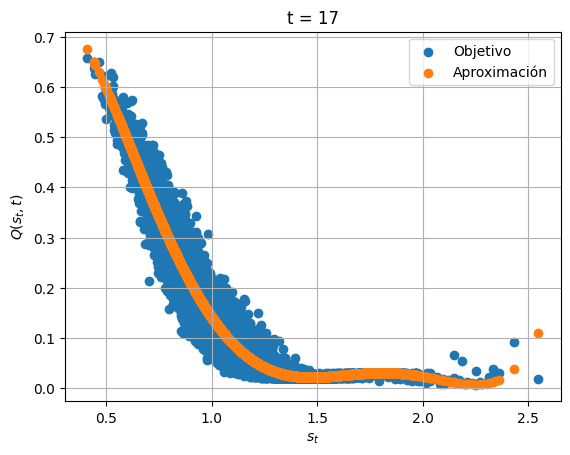

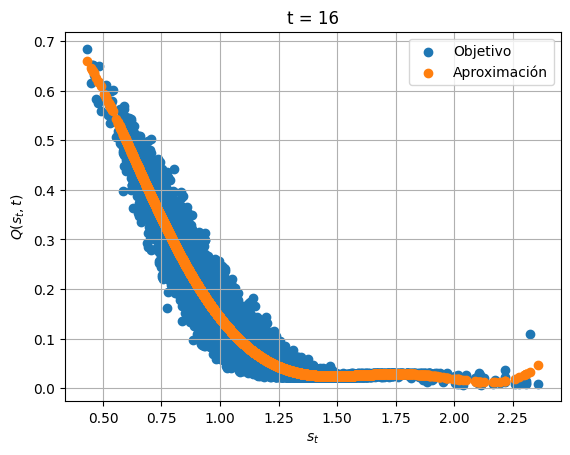

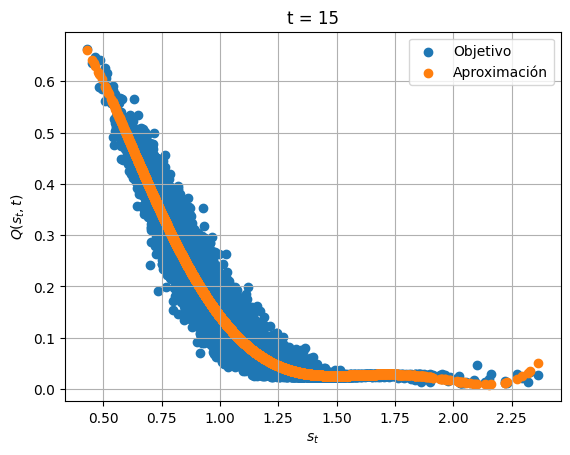

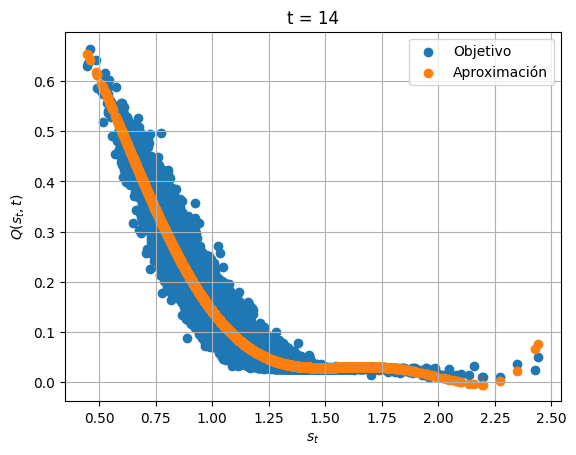

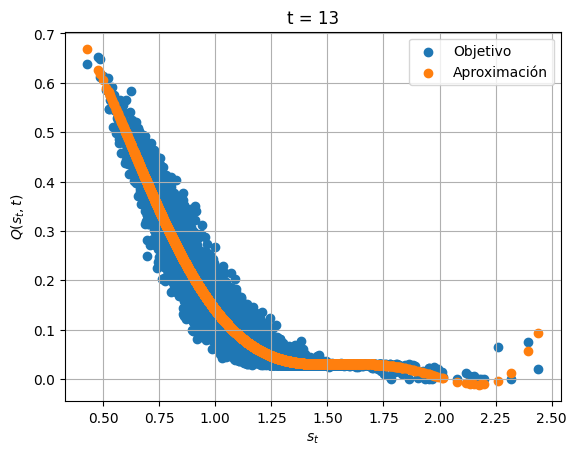

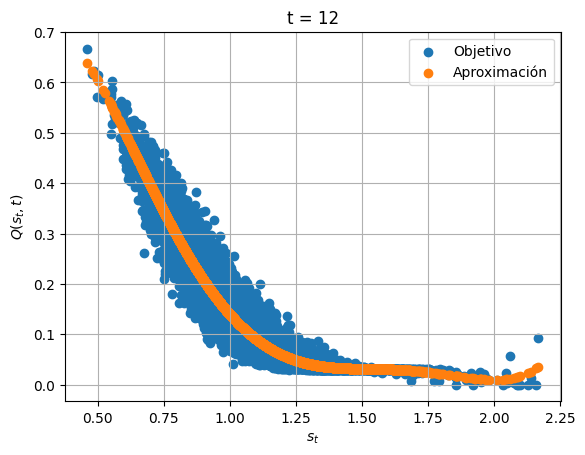

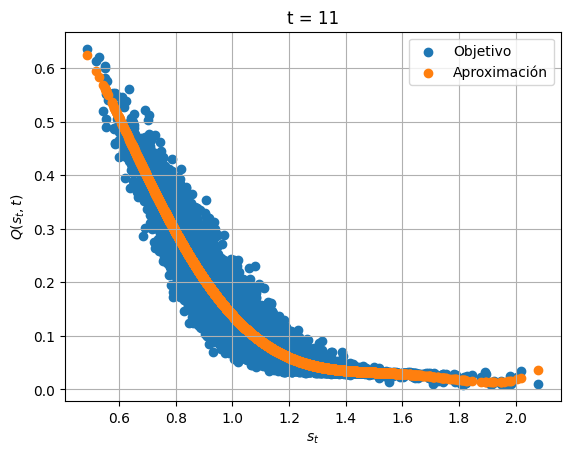

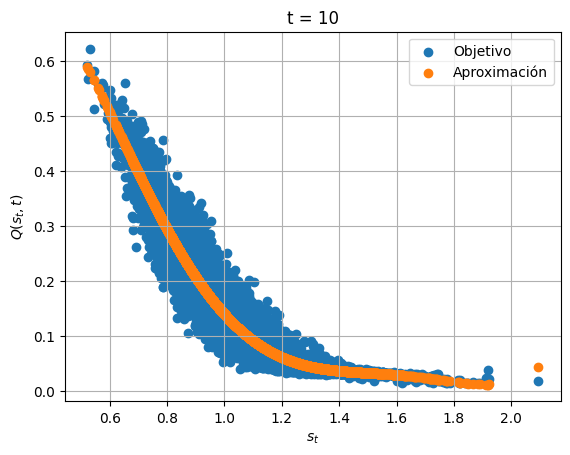

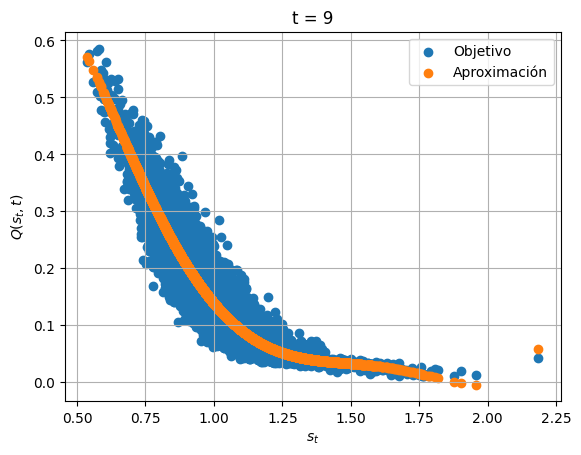

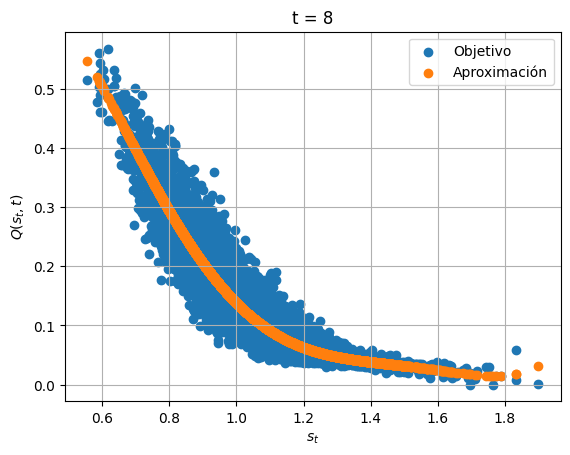

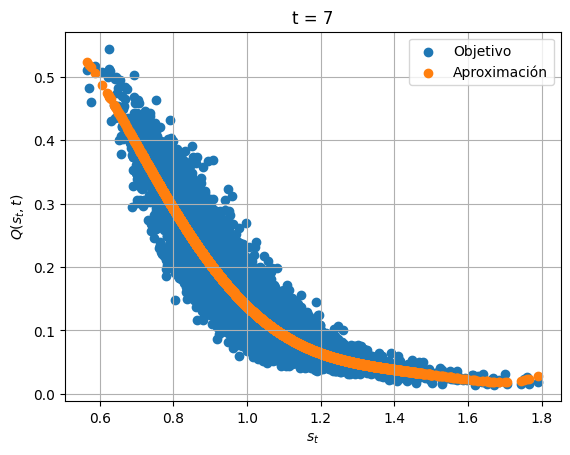

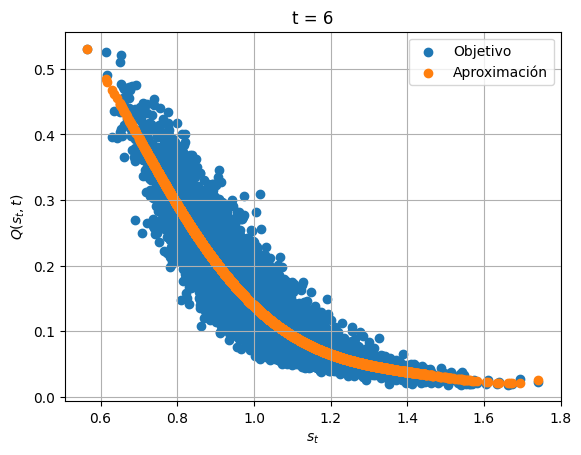

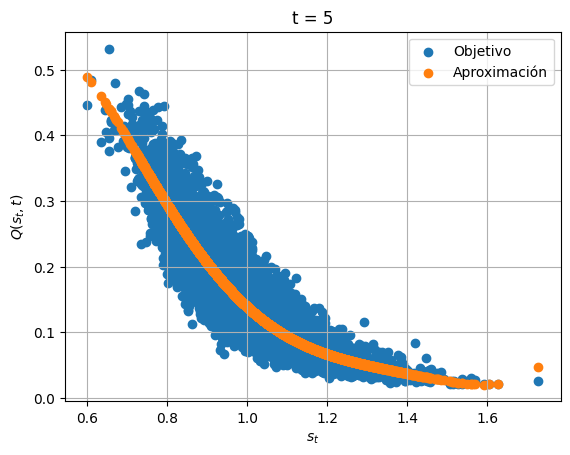

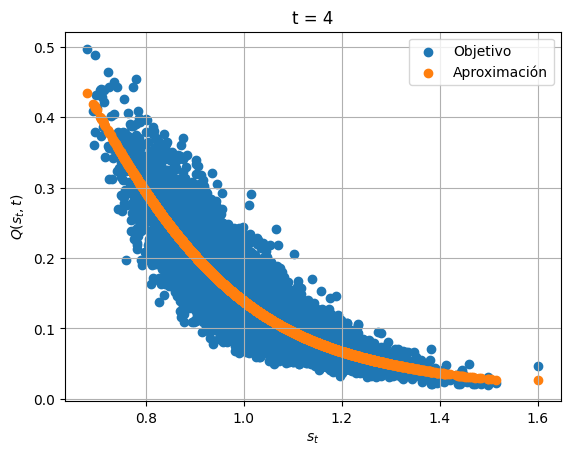

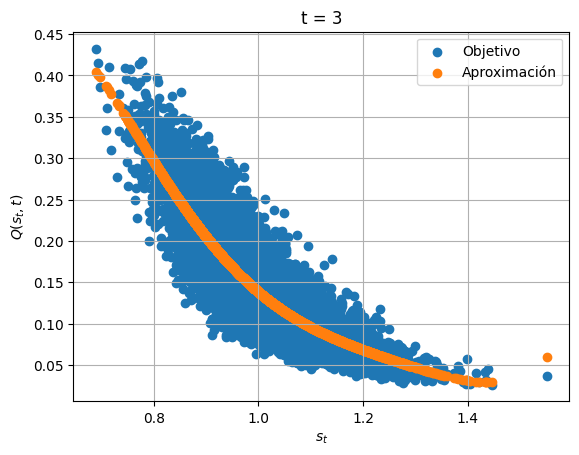

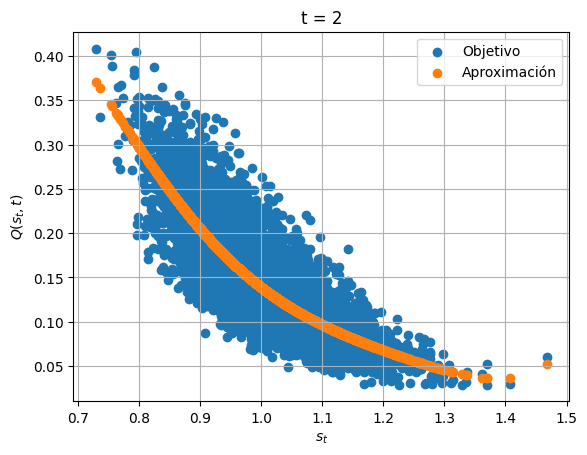

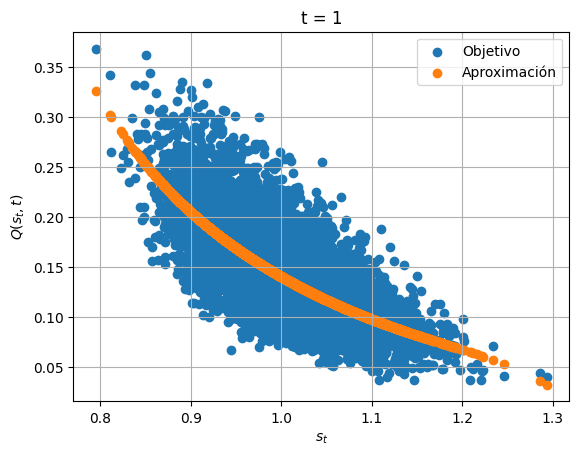

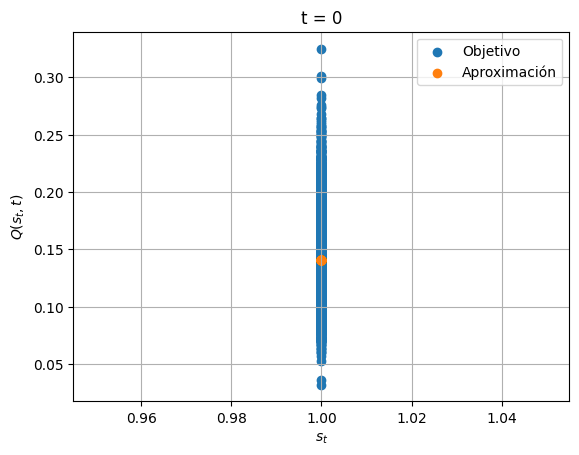

In [7]:
# Calculamos los pesos de las funciones básicas para cada periodo
w = np.zeros((T + 1, N + 1))
Q = np.zeros((M, T + 1))

for t in range(T - 1, -1, -1):
    # Queremos aproximar Q(s_t, t) con Phi(s_t) @ w_t
    A = np.vstack([Phi(S[i, t]) for i in range(M)])
    b = np.maximum(Q[:, t + 1], np.maximum(0, K - S[:, t + 1]))
    (w[t], tmp1, tmp2, tmp3) = np.linalg.lstsq(A, alpha * b)
    Q[:, t] = np.matmul(A, w[t])

    plt.scatter(S[:, t], alpha * b, label="Objetivo")
    plt.scatter(S[:, t], Q[:, t], label="Aproximación")
    plt.xlabel(r'$s_t$')
    plt.ylabel(r'$Q(s_t, t)$')
    plt.title(f"t = {t}")
    plt.grid(True)
    plt.legend()
    plt.show()


In [8]:
# Mostramos los datos y resultados de la aproximación para un periodo específico
t = 20
pd.DataFrame(
    data=np.vstack([
        S[:, t],
        S[:, t + 1],
        alpha * np.maximum(Q[:, t + 1], np.maximum(K - S[:, 36], 0)),
        Q[:, t],
    ]).T,
    columns=[
        's_t',
        's_{t+1}',
        'alpha*max(Q(s_{t+1}, t+1), K-s_{t+1}, 0)',
        'Q(s_t, t)',
    ],
)


,s_t,s_{t+1},"alpha*max(Q(s_{t+1}, t+1), K-s_{t+1}, 0)","Q(s_t, t)"
0,0.958113,1.003453,0.137203,0.166577
1,1.131147,1.099813,0.087277,0.074961
2,1.329443,1.303278,0.027787,0.025597
3,1.352646,1.217140,0.046001,0.022974
4,2.030760,1.983438,0.031642,0.028224
...,...,...,...,...
9995,0.690020,0.713144,0.376852,0.401997
9996,1.387594,1.403794,0.080862,0.020019
9997,1.084652,1.085856,0.110654,0.094755
9998,1.283039,1.317496,0.025643,0.032598


In [10]:
# Simulamos nuevas trayectorias para evaluar la política resultante
Mo = 50000
So = np.zeros((Mo, T + 1))
for i in range(Mo):
    So[i, 0] = S0
    for t in range(1, T + 1):
        So[i, t] = So[i, t - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * np.sqrt(dt) * np.random.randn())

# Calculamos la función valor a lo largo de las trayectorias de evaluación
Qo = np.zeros((Mo, T + 1))
for t in range(0, T):
    A = np.vstack([Phi(So[i, t]) for i in range(Mo)])
    Qo[:, t] = np.matmul(A, w[t])

# Política codiciosa: ejercer si el valor inmediato supera el valor de esperar
u = K - So[:, :-1] - np.maximum(Qo, 0) > 0
u = np.hstack([u, np.full((Mo, 1), fill_value=True)])
So = np.hstack([So, np.full((Mo, 1), fill_value=K)])

tau = np.argmax(u, axis=1)  # periodo en que se ejerce la opción en cada trayectoria
valor_estimado = np.mean(alpha**tau * np.maximum(K - So[range(Mo), tau], 0))
print('Valor de la opción =', valor_estimado)
print(f'Resolución con {N + 1} funciones básicas')


ValueError: operands could not be broadcast together with shapes (50000,36) (50000,37) 

In [ ]:
# tau indica el periodo en que la opción se ejerció; si no se ejerce, toma el valor final del arreglo.
tau


array([37, 37, 36, ...,  4, 16,  6])

In [ ]:
# Repetimos el proceso para distintos números de funciones básicas y de trayectorias
valor = {}
lista_N = range(2, 21, 2)  # número de funciones básicas
lista_M = [100, 1000, 10000, 20000, 50000]  # número de trayectorias

# Simulamos trayectorias adicionales para evaluar la política en todos los casos
Mo = 50000
So = np.zeros((Mo, T + 1))
for i in range(Mo):
    So[i, 0] = S0
    for t in range(1, T + 1):
        So[i, t] = So[i, t - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * np.sqrt(dt) * np.random.randn())
So = np.hstack([So, np.full((Mo, 1), fill_value=K)])

for M in lista_M:
    print(M, end  " ")
    # Simulamos trayectorias de entrenamiento
    S = np.zeros((M, T + 1))
    for i in range(M):
        S[i, 0] = S0
        for t in range(1, T + 1):
            S[i, t] = S[i, t - 1] * np.exp((r - sigma**2 / 2) * dt + sigma * np.sqrt(dt) * np.random.randn())

    for N in lista_N:
        print(N,end = " ")
    
        # Definimos las funciones básicas
        def Phi(s):
            return np.array([1] + [s**i for i in range(1, N + 1)])

        # Calculamos los pesos de las funciones básicas para cada periodo
        w = np.zeros((T + 1, N + 1))
        Q = np.zeros((M, T + 1))
        for t in range(T - 1, -1, -1):
            A = np.vstack([Phi(S[i, t]) for i in range(M)])
            b = np.maximum(Q[:, t + 1], np.maximum(0, K - S[:, t + 1]))
            (w[t], tmp1, tmp2, tmp3) = np.linalg.lstsq(A, alpha * b)
            Q[:, t] = np.matmul(A, w[t])

        # Calculamos la función valor a lo largo de las trayectorias de evaluación
        Qo = np.zeros((Mo, T + 1))
        for t in range(0, T):
            A = np.vstack([Phi(So[i, t]) for i in range(Mo)])
            Qo[:, t] = np.matmul(A, w[t])

        # Política codiciosa con respecto a la aproximación
        u = K - So[:, :-1] - np.maximum(Qo, 0) > 0
        u = np.hstack([u, np.full((Mo, 1), fill_value=True)])
        tau = np.argmax(u, axis=1) # en cada trayectoria, el primer periodo en que se ejerce la opción
        valor[(N, M)] = np.mean(alpha**tau * np.maximum(K - So[range(Mo), tau], 0))
    print()


2
3


In [ ]:
for M in lista_M:
    plt.plot([valor[(N, M)] for N in lista_N], label=f"M = {M}")
plt.legend()
plt.xlabel("Número de funciones básicas")
plt.ylabel("Valor de la opción")
plt.xticks(range(len(lista_N)), np.array(lista_N) + 1)
plt.grid(True)
plt.show()
